## Capstone Project
## Sales Analysis - New York and Connecticut

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [18]:
os.getcwd()

'C:\\Users\\danielbaptiste\\CSV Files'

In [19]:
os.listdir()

['customer_list.csv',
 'ProductCategories.csv',
 'Products.csv',
 'StoreDetail.csv',
 'StoreSales.csv']

In [20]:
os.chdir(r'C:\Users\danielbaptiste\CSV Files')   #Navigating into the folder containing the CSV files.
os.getcwd()
os.listdir()

['customer_list.csv',
 'ProductCategories.csv',
 'Products.csv',
 'StoreDetail.csv',
 'StoreSales.csv']

In [21]:
sales = pd.read_csv('StoreSales.csv') #Loading datasets into jupyter notebook.
products = pd.read_csv('Products.csv')
categories = pd.read_csv('ProductCategories.csv')
customers = pd.read_csv('customer_list.csv')
stores = pd.read_csv('StoreDetail.csv')

In [22]:
sales.head() #Viewing each dataset

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [23]:
stores.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [24]:
products.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [25]:
categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [26]:
customers.head()

,cust_id|date|time|name|email|phone|sms-opt-out
0,1|2023-03-15|08:45:12|Rachel|rachel@centralper...
1,2|2023-05-22|12:30:45|R. Geller|rossg@centralp...
2,3|2023-07-09|18:15:27|Monica Geller|chefmonica...
3,4|2023-09-01|21:05:33|Chandler Bing|chandlerb@...
4,5|2023-11-18|14:22:10|Joey|howyoudoing@central...


In [27]:
customers = pd.read_csv('customer_list.csv', sep='|') #Using a pipe seperator to clean the "Customers" dataset and make it easier to read.
customers.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [28]:
sales.info() #Seeing the different type of information in the datasets im working with


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [29]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [30]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [31]:
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [32]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


## Core Marketing Analysis

In [33]:
stores[stores['State'].isin(['Connecticut', 'New York'])] #List stores in Connecticut and New York this is how I found the information I needed for question 1.

,Store Location,State,Store ID,Territory Manager,Region,Region Director
18,Bridgeport,Connecticut,865,Ellen Lemon,East,Ana Jilani
19,Darien,Connecticut,866,Ellen Lemon,East,Ana Jilani
20,Hartford,Connecticut,867,Ellen Lemon,East,Ana Jilani
21,Litchfield County,Connecticut,868,Ellen Lemon,East,Ana Jilani
22,New Haven,Connecticut,869,Ellen Lemon,East,Ana Jilani
23,New London,Connecticut,870,Ellen Lemon,East,Ana Jilani
24,Old Saybrook,Connecticut,871,Ellen Lemon,East,Ana Jilani
25,Waterbury,Connecticut,872,Ellen Lemon,East,Ana Jilani
86,Albany,New York,840,See Ellefson,East,Ana Jilani
87,Buffalo,New York,841,See Ellefson,East,Ana Jilani


In [34]:
east_stores = stores[stores['State'].isin(['Connecticut', 'New York'])] #I used east_stores as a variable to store Connecticut and New York.

In [35]:
east_stores[['Territory Manager', 'Store ID', 'Store Location', 'State']] #Display the specific columns for the analysis. 

,Territory Manager,Store ID,Store Location,State
18,Ellen Lemon,865,Bridgeport,Connecticut
19,Ellen Lemon,866,Darien,Connecticut
20,Ellen Lemon,867,Hartford,Connecticut
21,Ellen Lemon,868,Litchfield County,Connecticut
22,Ellen Lemon,869,New Haven,Connecticut
23,Ellen Lemon,870,New London,Connecticut
24,Ellen Lemon,871,Old Saybrook,Connecticut
25,Ellen Lemon,872,Waterbury,Connecticut
86,See Ellefson,840,Albany,New York
87,See Ellefson,841,Buffalo,New York


## 1. The territory managers are Ellen Lemon and See Ellefson. Ellen manages the Connecticut territory while See manages the New York Territory. The store IDs for the Connecticut locatoins are between 865 and 871 where the store IDs for the New York locations are between 840 and 851.

In [36]:
east_sales = pd.merge(sales, stores, on='Store ID') #Merge the sales and store datasets using Store ID 

In [37]:
east_sales = east_sales[east_sales['State'].isin(['Connecticut', 'New York'])] #Filter for Connecticut and New York sales only

In [38]:
east_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
117,1/1/2022,840,NaN,105315-IT,34.43,Albany,New York,See Ellefson,East,Ana Jilani
118,1/1/2022,842,NaN,105346-IT,318.96,Elmira,New York,See Ellefson,East,Ana Jilani
119,1/1/2022,843,47.0,105349-M,8.00,Ithaca,New York,See Ellefson,East,Ana Jilani
120,1/1/2022,844,NaN,105446-B,12.70,Oswego,New York,See Ellefson,East,Ana Jilani
121,1/1/2022,845,NaN,105447-M,50.96,Plattsburgh,New York,See Ellefson,East,Ana Jilani


In [39]:
east_sales['Transaction Date'] = pd.to_datetime(east_sales['Transaction Date']) #convert transaction date to date time format

In [40]:
east_sales['Month'] = east_sales['Transaction Date'].dt.to_period('M') #Create a month column from transaction date

In [41]:
monthly_revenue = east_sales.groupby(['Month', 'State'])['Sale Amount'].sum() #Group sales by month and state and calculate the total revenue

In [42]:
monthly_revenue

Month    State      
2022-01  Connecticut     29958.25
         New York        58635.53
2022-02  Connecticut     25563.98
         New York        60262.97
2022-03  Connecticut     33995.57
                          ...    
2025-10  New York       185241.67
2025-11  Connecticut     59762.07
         New York       126941.06
2025-12  Connecticut     92791.01
         New York       128272.56
Name: Sale Amount, Length: 96, dtype: float64

In [43]:
monthly_revenue.reset_index() #Cleaning the dataset to make it more readable.

,Month,State,Sale Amount
0,2022-01,Connecticut,29958.25
1,2022-01,New York,58635.53
2,2022-02,Connecticut,25563.98
3,2022-02,New York,60262.97
4,2022-03,Connecticut,33995.57
...,...,...,...
91,2025-10,New York,185241.67
92,2025-11,Connecticut,59762.07
93,2025-11,New York,126941.06
94,2025-12,Connecticut,92791.01


In [44]:
pd.set_option('display.max_rows',100) #Show all rows so monthly totals are easier to read.
monthly_revenue.reset_index()

,Month,State,Sale Amount
0,2022-01,Connecticut,29958.25
1,2022-01,New York,58635.53
2,2022-02,Connecticut,25563.98
3,2022-02,New York,60262.97
4,2022-03,Connecticut,33995.57
5,2022-03,New York,57143.40
6,2022-04,Connecticut,31587.12
7,2022-04,New York,56880.02
8,2022-05,Connecticut,37953.48
9,2022-05,New York,51805.22


## 2 The chart above displays the sum of the month by month total revenue for sales year 2022-2025.

In [45]:
store_sales = east_sales.groupby(['Store Location', 'State'])['Sale Amount'].sum().reset_index()

In [46]:
store_sales = store_sales.sort_values(by='Sale Amount', ascending=False) #Sort stores from highest to lowest total sales
store_sales

,Store Location,State,Sale Amount
11,New York,New York,621565.02
17,Rochester,New York,607148.21
15,Poestenkill,New York,334175.88
10,New London,Connecticut,331116.76
1,Bridgeport,Connecticut,322100.07
3,Buffalo,New York,314979.99
5,Elmira,New York,313971.65
7,Ithaca,New York,313920.05
14,Plattsburgh,New York,311520.52
0,Albany,New York,310389.02


In [47]:
ny_sales = store_sales[store_sales['State'] == 'New York'] #Filter store rankings to only show New York stores.
ny_sales

,Store Location,State,Sale Amount
11,New York,New York,621565.02
17,Rochester,New York,607148.21
15,Poestenkill,New York,334175.88
3,Buffalo,New York,314979.99
5,Elmira,New York,313971.65
7,Ithaca,New York,313920.05
14,Plattsburgh,New York,311520.52
0,Albany,New York,310389.02
18,Syracuse,New York,306998.14
2,Brooklyn,New York,304732.76


In [48]:
ct_sales = store_sales[store_sales['State'] == 'Connecticut'] #Filter store rankings to only show New York stores.
ct_sales

,Store Location,State,Sale Amount
10,New London,Connecticut,331116.76
1,Bridgeport,Connecticut,322100.07
6,Hartford,Connecticut,309592.06
19,Waterbury,Connecticut,295651.17
9,New Haven,Connecticut,286779.43
8,Litchfield County,Connecticut,286217.15
4,Darien,Connecticut,283455.62
12,Old Saybrook,Connecticut,277310.18


## 3 The top performing store in New York is located in Manhattan and the top performing store in Connecticut is located in New London.

In [49]:
customer_sales = pd.merge(   #Merge sales and customer data using RewardsID and cusotmer ID
    east_sales,
    customers,
    left_on='RewardsID',
    right_on='cust_id'
)

In [50]:
top_customers = customer_sales.groupby(['name','State'])['Sale Amount'].sum().reset_index() #Calculate total spending for each customer by territory

In [51]:
top_customers = top_customers.sort_values(by='Sale Amount', ascending=False) #Sort customers from highest to lowest spending 
top_customers

,name,State,Sale Amount
505,Julian Bashir,New York,6039.32
636,Marie S.,Connecticut,4388.87
453,Jason Morgan,New York,3918.72
653,Mellie Grant,New York,3805.61
496,Jon Snow,Connecticut,3676.21
...,...,...,...
953,Tyrion L.,Connecticut,8.45
694,Mr. Burns,Connecticut,6.02
226,Daniel Tiger,New York,6.02
450,Jason Mendoza,Connecticut,6.00


In [52]:
top_customers[top_customers['State'] == 'New York']

,name,State,Sale Amount
505,Julian Bashir,New York,6039.32
453,Jason Morgan,New York,3918.72
653,Mellie Grant,New York,3805.61
749,Peggy Olson,New York,3504.20
360,Gonzo,New York,3441.19
...,...,...,...
671,Miles O'Brien,New York,26.40
707,Mrs. Trumbull,New York,24.70
267,Donna Moss,New York,17.70
352,Gina Waters,New York,12.15


In [53]:
top_customers[top_customers['State'] == 'Connecticut']

,name,State,Sale Amount
636,Marie S.,Connecticut,4388.87
496,Jon Snow,Connecticut,3676.21
315,Fox Mulder,Connecticut,3569.60
778,Pugsley A.,Connecticut,3009.29
391,Helen M.,Connecticut,2886.72
...,...,...,...
442,James Hurley,Connecticut,9.09
953,Tyrion L.,Connecticut,8.45
694,Mr. Burns,Connecticut,6.02
450,Jason Mendoza,Connecticut,6.00


## 4 In the New York territory Julian Bashir was the top customer and in the Connecticut territory, Marie S. was the top customer.

## 5 part i.

In [54]:
product_sales = pd.merge(    #Merge sales and product data using product number.
    east_sales,
    products,
    on='Prod Num'
)

In [55]:
category_transactions = product_sales.groupby(    #Count transactions per month by territory and product category. Prod Num refers to the amount of transactions for that item category
    ['Month', 'State', 'CategoryID']
)['Prod Num'].count().reset_index()
category_transactions

,Month,State,CategoryID,Prod Num
0,2022-01,Connecticut,100,31
1,2022-01,Connecticut,110,36
2,2022-01,Connecticut,115,29
3,2022-01,Connecticut,120,45
4,2022-01,Connecticut,125,19
...,...,...,...,...
571,2025-12,New York,110,191
572,2025-12,New York,115,127
573,2025-12,New York,120,228
574,2025-12,New York,125,76


In [56]:
category_transactions[     #Show new york transaction counts by month and category
    category_transactions['State'] == 'New York'
    ]

,Month,State,CategoryID,Prod Num
6,2022-01,New York,100,78
7,2022-01,New York,110,74
8,2022-01,New York,115,51
9,2022-01,New York,120,73
10,2022-01,New York,125,24
...,...,...,...,...
571,2025-12,New York,110,191
572,2025-12,New York,115,127
573,2025-12,New York,120,228
574,2025-12,New York,125,76


In [57]:
category_transactions[    #Show Connecticut transaction counts by month and category
    category_transactions['State'] == 'Connecticut'
    ]

,Month,State,CategoryID,Prod Num
0,2022-01,Connecticut,100,31
1,2022-01,Connecticut,110,36
2,2022-01,Connecticut,115,29
3,2022-01,Connecticut,120,45
4,2022-01,Connecticut,125,19
...,...,...,...,...
565,2025-12,Connecticut,110,106
566,2025-12,Connecticut,115,91
567,2025-12,Connecticut,120,132
568,2025-12,Connecticut,125,40


## 5 part ii.

In [58]:
category_revenue = product_sales.groupby(   #Calculate total monthly sales revenue by territory and product category.
    ['Month', 'State', 'CategoryID']
)['Sale Amount'].sum().reset_index()

category_revenue

,Month,State,CategoryID,Sale Amount
0,2022-01,Connecticut,100,5397.73
1,2022-01,Connecticut,110,334.49
2,2022-01,Connecticut,115,653.12
3,2022-01,Connecticut,120,21860.06
4,2022-01,Connecticut,125,489.60
...,...,...,...,...
571,2025-12,New York,110,2062.97
572,2025-12,New York,115,3562.18
573,2025-12,New York,120,97801.03
574,2025-12,New York,125,2140.93


In [59]:
category_revenue[
    category_revenue['State'] == 'Connecticut'
    ]

,Month,State,CategoryID,Sale Amount
0,2022-01,Connecticut,100,5397.73
1,2022-01,Connecticut,110,334.49
2,2022-01,Connecticut,115,653.12
3,2022-01,Connecticut,120,21860.06
4,2022-01,Connecticut,125,489.60
...,...,...,...,...
565,2025-12,Connecticut,110,1073.41
566,2025-12,Connecticut,115,2969.29
567,2025-12,Connecticut,120,74810.44
568,2025-12,Connecticut,125,1399.52


In [60]:
category_revenue[
    category_revenue['State'] == 'New York'
    ]

,Month,State,CategoryID,Sale Amount
6,2022-01,New York,100,13818.45
7,2022-01,New York,110,750.97
8,2022-01,New York,115,1130.99
9,2022-01,New York,120,39954.00
10,2022-01,New York,125,776.97
...,...,...,...,...
571,2025-12,New York,110,2062.97
572,2025-12,New York,115,3562.18
573,2025-12,New York,120,97801.03
574,2025-12,New York,125,2140.93


In [61]:
top_categories = category_revenue.groupby(
    'CategoryID'
)['Sale Amount'].sum().sort_values(ascending=False)
top_categories

CategoryID
120    4779056.69
100    1175355.25
130     305367.03
115     249883.83
125     110512.08
110     102864.65
Name: Sale Amount, dtype: float64

In [62]:
categories[['CategoryID', 'Category']].drop_duplicates()

,CategoryID,Category
0,120,Technology & Accessories
7,130,Apparel and Merchandise
8,100,Textbooks
11,115,Art Supplies
12,125,Books (General)
13,110,Stationery and Supplies


## 5 part iii.

## Technology and accessories generated the highest total sales revenue, followed by textbooks. 
## This proves that these product categories were the most popular and consistently purchased.
## General books and art supplies earned the lowest total sales revenue which can suggest lower demand or fewer transactions.
## These lower performing categories can mean opportunities for growth in these areas can be attained through improved marketing strategies
## and/or competitive pricing

## 6. Based on the sales and revenue data, I would suggest to maintain sales focus on technology and accessories because it generated the highest sales
## and seem to be the most popular product category across the sales territories. If we continue to market the items from this category
## it can help maintain a strong customer demand and increase repeat purchases. On the other hand, much more marketing attention
## should be aimed to the lower performing categories such as general art and textbooks to explore more opportunites for sales growth and building a larger customer base within these categories.


## Revenue by Product Category chart

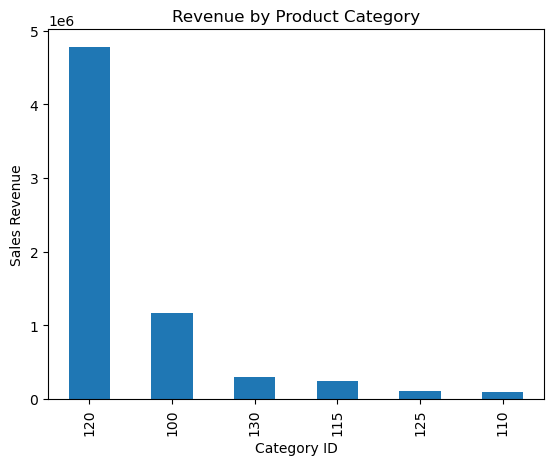

In [63]:
top_categories.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Category ID')
plt.ylabel('Sales Revenue')

plt.show()

## Monthly sales revenue trend 

<function matplotlib.pyplot.show(close=None, block=None)>

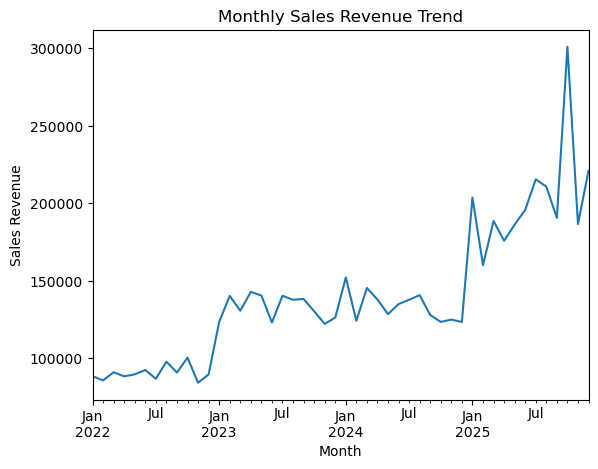

In [64]:
monthly_revenue = category_revenue.groupby('Month')['Sale Amount'].sum()
monthly_revenue.plot(kind='line')

plt.title('Monthly Sales Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Sales Revenue')

plt.show